# 02 — Pogoda historyczna z Open-Meteo Archive

Pobranie godzinowych danych pogodowych dla 5 lokalizacji w Polsce z reanalizy ERA5, zakres 2023-01-01 → 2025-12-31. Wynik: `data/processed/pogoda_2023_2025.csv`.

Pełny opis projektu w README.

## Źródło danych

[Open-Meteo Archive API](https://open-meteo.com/en/docs/historical-weather-api) — endpoint `https://archive-api.open-meteo.com/v1/archive`. Bez autoryzacji, JSON, dane oparte na reanalizie **ERA5** (Hersbach et al., 2020) — referencyjnym zbiorze klimatycznym ECMWF. Rozdzielczość godzinowa, dostępne wstecz do 1940 r.

## Wybór lokalizacji

| Punkt | Lat | Lon | Województwo | Argumentacja |
|---|---|---|---|---|
| Szczecin | 53.43 | 14.55 | zachodniopomorskie | lider mocy zainstalowanej w wiatrakach (~2 GW, IEO 2024) |
| Słupsk | 54.46 | 17.03 | pomorskie | drugi region wiatrowy, bliskość Bałtyku |
| Bydgoszcz | 53.12 | 18.01 | kujawsko-pomorskie | duża liczba farm wiatrowych, region Wielkopolska/Kujawy |
| Warszawa | 52.23 | 21.01 | mazowieckie | centrum kraju, mix |
| Kraków | 50.06 | 19.94 | małopolskie | południe — najwyższe nasłonecznienie roczne, PV |

Wybór odzwierciedla rzeczywiste rozmieszczenie mocy zainstalowanej OZE w Polsce. Według raportu Instytutu Energetyki Odnawialnej z marca 2024 r., trzy województwa północne (zachodniopomorskie, pomorskie, kujawsko-pomorskie) skupiają większość mocy wiatrowej onshore. Fotowoltaika jest rozłożona równomierniej, z lekką przewagą południa ze względu na nasłonecznienie. 5 punktów rozproszonych po Polsce daje sygnał skorelowany z agregatem krajowym lepiej niż jedna lokalizacja "centralna" — sieć neuronowa może się sama nauczyć wag dla różnych regionów.

## Wybór zmiennych pogodowych

Z dziesiątek dostępnych zmiennych Open-Meteo wybraliśmy 7, które są bezpośrednio związane z fizyką generacji wiatrowej i fotowoltaicznej:

**Wiatr (3 zmienne):**

| Zmienna | Po co |
|---|---|
| `wind_speed_100m` | prędkość wiatru na wysokości wirnika nowoczesnych turbin (~100 m); generacja rośnie z $v^3$ do prędkości znamionowej |
| `wind_direction_100m` | kierunek wiatru — różne kierunki różnie obciążają turbiny (efekt zacienienia aerodynamicznego, profil pionowy wiatru) |
| `wind_speed_10m` | wiatr przy gruncie; skorelowany z `100m`, ale zawiera dodatkowy sygnał o stratyfikacji atmosfery |

**Promieniowanie i temperatura (4 zmienne):**

| Zmienna | Po co |
|---|---|
| `shortwave_radiation` | całkowite promieniowanie krótkofalowe — najsilniejszy predyktor PV |
| `direct_radiation` | promieniowanie bezpośrednie — istotne dla paneli z trackerem (większe instalacje), różnicuje pogodę bezchmurną od rozproszonej |
| `cloud_cover` | zachmurzenie — częściowo skorelowane z radiacją, ale przy zmiennym zachmurzeniu daje dodatkowy sygnał |
| `temperature_2m` | temperatura paneli PV — przy wysokiej temp. spada sprawność (ok. −0.4%/°C powyżej 25°C) |

Świadomie pominęliśmy:
- `relative_humidity_2m` — w pracach o prognozie PV deep learning rzadko używana, silnie skorelowana z `cloud_cover`
- `wind_speed_80m`, `wind_speed_120m` — wysoko skorelowane z `wind_speed_100m`, redundantne
- ciśnienie, opady — drugorzędne dla generacji OZE w stosunku do wiatru i radiacji

Łącznie: **7 zmiennych × 5 lokalizacji = 35 cech pogodowych** na każdą godzinę.

## Literatura referencyjna

- **Wang, H., Lei, Z., Zhang, X., Zhou, B., & Peng, J.** (2019). *A review of deep learning for renewable energy forecasting*. Energy Conversion and Management, 198, 111799. — przegląd architektur DL dla prognozy OZE, omówienie typowych zestawów cech pogodowych
- **Hersbach, H. et al.** (2020). *The ERA5 global reanalysis*. QJRMS, 146(730), 1999–2049. — referencyjny opis zbioru danych ERA5
- **Instytut Energetyki Odnawialnej** (2024). *Funkcjonujące Elektrownie i Farmy Wiatrowe w Polsce 2024* — rozkład geograficzny mocy zainstalowanej

## 2.2.1 Konfiguracja

In [7]:
import time
from pathlib import Path

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

WEATHER_DIR = Path("data/pogoda")
OUTPUT_DIR = Path("data/processed")
WEATHER_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OPEN_METEO_URL = "https://archive-api.open-meteo.com/v1/archive"

LOCATIONS = {
    "szczecin":  (53.43, 14.55),
    "slupsk":    (54.46, 17.03),
    "bydgoszcz": (53.12, 18.01),
    "warszawa":  (52.23, 21.01),
    "krakow":    (50.06, 19.94),
}

FEATURES = [
    "wind_speed_100m",
    "wind_direction_100m",
    "wind_speed_10m",
    "shortwave_radiation",
    "direct_radiation",
    "cloud_cover",
    "temperature_2m",
]

DATE_FROM = "2023-01-01"
DATE_TO   = "2025-12-31"

print(f"lokalizacje: {len(LOCATIONS)}, featury: {len(FEATURES)}")
print(f"zakres: {DATE_FROM} -> {DATE_TO}")

lokalizacje: 5, featury: 7
zakres: 2023-01-01 -> 2025-12-31


Lokalizacje, lista zmiennych pogodowych, zakres dat.

## 2.2.2 Pobieranie pogody dla pojedynczej lokalizacji

In [8]:
def fetch_weather(name: str, lat: float, lon: float) -> pd.DataFrame:
    cache_file = WEATHER_DIR / f"pogoda_{name}.csv"
    if cache_file.exists():
        return pd.read_csv(cache_file, parse_dates=["timestamp"])

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": DATE_FROM,
        "end_date": DATE_TO,
        "hourly": ",".join(FEATURES),
        "timezone": "Europe/Warsaw",
        "wind_speed_unit": "ms",
    }

    r = requests.get(OPEN_METEO_URL, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()["hourly"]

    df = pd.DataFrame(data).rename(columns={"time": "timestamp"})
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df.to_csv(cache_file, index=False)
    return df


# smoke test
df_test = fetch_weather("warszawa", *LOCATIONS["warszawa"])
print(f"wierszy: {len(df_test)}, kolumny: {list(df_test.columns)}")
df_test.head()

wierszy: 26304, kolumny: ['timestamp', 'wind_speed_100m', 'wind_direction_100m', 'wind_speed_10m', 'shortwave_radiation', 'direct_radiation', 'cloud_cover', 'temperature_2m']


,timestamp,wind_speed_100m,wind_direction_100m,wind_speed_10m,shortwave_radiation,direct_radiation,cloud_cover,temperature_2m
0,2023-01-01 00:00:00,11.18,234,6.39,0.0,0.0,100,12.9
1,2023-01-01 01:00:00,11.32,234,6.53,0.0,0.0,100,13.2
2,2023-01-01 02:00:00,12.04,242,6.96,0.0,0.0,100,13.8
3,2023-01-01 03:00:00,11.65,237,6.64,0.0,0.0,100,13.8
4,2023-01-01 04:00:00,11.96,234,6.90,0.0,0.0,100,13.4


Funkcja pobiera pogodę dla jednej lokalizacji w pełnym zakresie dat. Cache jako CSV — drugie uruchomienie idzie z dysku. Strefa czasowa `Europe/Warsaw` żeby zgadzała się z PSE.

## 2.2.3 Pobranie wszystkich 5 lokalizacji

In [9]:
weather = {}
for name, (lat, lon) in LOCATIONS.items():
    print(f"  {name}...", end=" ")
    weather[name] = fetch_weather(name, lat, lon)
    print(f"{len(weather[name])} wierszy")
    time.sleep(0.5)

  szczecin... 26304 wierszy
  slupsk... 26304 wierszy
  bydgoszcz... 26304 wierszy
  warszawa... 26304 wierszy
  krakow... 26304 wierszy


Pętla po lokalizacjach.

## 2.2.4 Sklejenie w jeden DataFrame

In [10]:
frames = []
for name, df in weather.items():
    df_renamed = df.rename(columns={
        "wind_speed_100m":     f"wind100_{name}",
        "wind_direction_100m": f"wdir100_{name}",
        "wind_speed_10m":      f"wind10_{name}",
        "shortwave_radiation": f"rad_{name}",
        "direct_radiation":    f"rad_dir_{name}",
        "cloud_cover":         f"cloud_{name}",
        "temperature_2m":      f"temp_{name}",
    })
    frames.append(df_renamed.set_index("timestamp"))

df = pd.concat(frames, axis=1)
print(f"wierszy: {len(df)}, kolumn: {df.shape[1]}")
print(f"zakres: {df.index.min()} -> {df.index.max()}")
df.head()

wierszy: 26304, kolumn: 35
zakres: 2023-01-01 00:00:00 -> 2025-12-31 23:00:00


,wind100_szczecin,wdir100_szczecin,wind10_szczecin,rad_szczecin,rad_dir_szczecin,cloud_szczecin,temp_szczecin,wind100_slupsk,wdir100_slupsk,wind10_slupsk,...,rad_dir_warszawa,cloud_warszawa,temp_warszawa,wind100_krakow,wdir100_krakow,wind10_krakow,rad_krakow,rad_dir_krakow,cloud_krakow,temp_krakow
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,13.23,227,8.13,0.0,0.0,100,14.9,12.66,243,7.56,...,0.0,100,12.9,8.10,243,3.10,0.0,0.0,100,10.1
2023-01-01 01:00:00,13.09,227,7.92,0.0,0.0,100,14.3,13.82,232,8.51,...,0.0,100,13.2,8.80,234,3.45,0.0,0.0,100,10.9
2023-01-01 02:00:00,12.63,229,7.43,0.0,0.0,100,13.9,10.98,232,6.31,...,0.0,100,13.8,10.32,225,4.88,0.0,0.0,99,12.9
2023-01-01 03:00:00,13.27,230,7.99,0.0,0.0,100,14.6,14.53,236,8.94,...,0.0,100,13.8,10.04,225,4.67,0.0,0.0,96,12.8
2023-01-01 04:00:00,13.67,232,8.44,0.0,0.0,100,15.3,14.40,236,8.88,...,0.0,100,13.4,10.26,228,4.75,0.0,0.0,99,12.9


Sklejone na wspólnym timestampie. Każda lokalizacja dodaje 7 kolumn z sufiksem nazwy miasta.

In [11]:
print(f"NaN-y: {df.isna().sum().sum()}")
expected = pd.date_range(df.index.min(), df.index.max(), freq="1h")
missing = expected.difference(df.index)
print(f"oczekiwane godziny: {len(expected)}, faktyczne: {len(df)}, brakujące: {len(missing)}")

NaN-y: 0
oczekiwane godziny: 26304, faktyczne: 26304, brakujące: 0


Sprawdzenie kompletności. Spodziewamy się 26 304 wierszy (3 lata × 8760h + DST).

## 2.2.5 Konwersja kierunku wiatru

`wind_direction_100m` jest wartością kątową w stopniach (0–360°).Kąty są cykliczne. Konwertujemy na sinus i cosinus, dzięki czemu cykliczność jest zachowana w przestrzeni cech.

In [12]:
for name in LOCATIONS:
    rad = np.deg2rad(df[f"wdir100_{name}"])
    df[f"wdir100_sin_{name}"] = np.sin(rad)
    df[f"wdir100_cos_{name}"] = np.cos(rad)
    df = df.drop(columns=[f"wdir100_{name}"])

print(f"kolumn po konwersji: {df.shape[1]}")
df.head()

kolumn po konwersji: 40


,wind100_szczecin,wind10_szczecin,rad_szczecin,rad_dir_szczecin,cloud_szczecin,temp_szczecin,wind100_slupsk,wind10_slupsk,rad_slupsk,rad_dir_slupsk,...,wdir100_sin_szczecin,wdir100_cos_szczecin,wdir100_sin_slupsk,wdir100_cos_slupsk,wdir100_sin_bydgoszcz,wdir100_cos_bydgoszcz,wdir100_sin_warszawa,wdir100_cos_warszawa,wdir100_sin_krakow,wdir100_cos_krakow
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,13.23,8.13,0.0,0.0,100,14.9,12.66,7.56,0.0,0.0,...,-0.731354,-0.681998,-0.891007,-0.453990,-0.838671,-0.544639,-0.809017,-0.587785,-0.891007,-0.453990
2023-01-01 01:00:00,13.09,7.92,0.0,0.0,100,14.3,13.82,8.51,0.0,0.0,...,-0.731354,-0.681998,-0.788011,-0.615661,-0.857167,-0.515038,-0.809017,-0.587785,-0.809017,-0.587785
2023-01-01 02:00:00,12.63,7.43,0.0,0.0,100,13.9,10.98,6.31,0.0,0.0,...,-0.754710,-0.656059,-0.788011,-0.615661,-0.848048,-0.529919,-0.882948,-0.469472,-0.707107,-0.707107
2023-01-01 03:00:00,13.27,7.99,0.0,0.0,100,14.6,14.53,8.94,0.0,0.0,...,-0.766044,-0.642788,-0.829038,-0.559193,-0.819152,-0.573576,-0.838671,-0.544639,-0.707107,-0.707107
2023-01-01 04:00:00,13.67,8.44,0.0,0.0,100,15.3,14.40,8.88,0.0,0.0,...,-0.788011,-0.615661,-0.829038,-0.559193,-0.891007,-0.453990,-0.809017,-0.587785,-0.743145,-0.669131


Z 35 kolumn (5 lok × 7 featurów) zrobiło się 40 kolumn (5 lok × 8 featurów po rozbiciu kierunku na sin/cos).

## 2.2.6 Smoke test

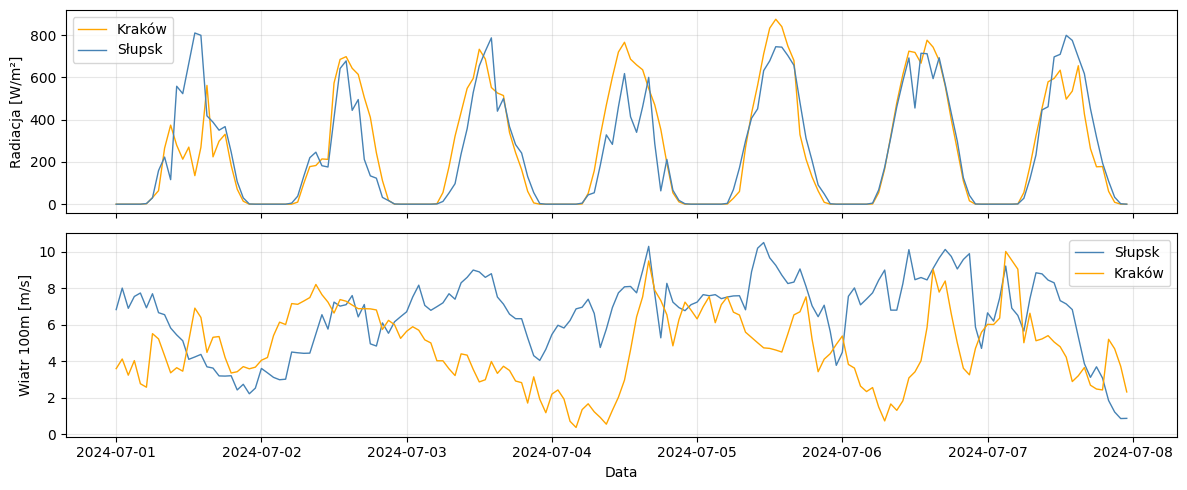

In [13]:
sample = df.loc["2024-07-01":"2024-07-07"]

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(sample.index, sample["rad_krakow"], color="orange", label="Kraków", lw=1)
axes[0].plot(sample.index, sample["rad_slupsk"], color="steelblue", label="Słupsk", lw=1)
axes[0].set_ylabel("Radiacja [W/m²]")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(sample.index, sample["wind100_slupsk"], color="steelblue", label="Słupsk", lw=1)
axes[1].plot(sample.index, sample["wind100_krakow"], color="orange", label="Kraków", lw=1)
axes[1].set_ylabel("Wiatr 100m [m/s]")
axes[1].set_xlabel("Data")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Tydzień lipca 2024. Radiacja: oba miasta mają wyraźny cykl dobowy z zerem w nocy, Kraków zwykle wyżej (więcej słońca rocznie). Wiatr: Słupsk silniejszy od Krakowa (bliskość Bałtyku, mniejsza orografia).

In [14]:
temp_cols = [f"temp_{name}" for name in LOCATIONS]
yearly_temp = df[temp_cols].groupby(df.index.year).mean().round(1)
yearly_temp.columns = list(LOCATIONS.keys())
print("Średnia roczna temperatura [°C]:")
print(yearly_temp)

Średnia roczna temperatura [°C]:
           szczecin  slupsk  bydgoszcz  warszawa  krakow
timestamp                                               
2023           10.4     9.7       10.3      10.6    10.7
2024           11.3    10.6       11.2      11.5    11.5
2025           10.1     9.2        9.9      10.1    10.0


Kraków zwykle najcieplejszy (kontynentalny klimat), Słupsk najchłodniejszy w lecie ale łagodniejszy w zimie (wpływ morza).

## 2.2.7 Zapis

In [15]:
output_file = OUTPUT_DIR / "pogoda_2023_2025.csv"
df.to_csv(output_file, sep=";", decimal=",")
print(f"zapisano: {output_file}")
print(f"wierszy: {len(df)}, kolumn: {df.shape[1]}")

zapisano: data/processed/pogoda_2023_2025.csv
wierszy: 26304, kolumn: 40


## Podsumowanie sekcji 2.2

Zbiór danych pogodowych: **26 304 wiersze**, **40 kolumn** (5 lokalizacji × 8 cech: prędkość wiatru na 100m i 10m, sin i cos kierunku wiatru na 100m, radiacja całkowita, radiacja bezpośrednia, zachmurzenie, temperatura), okres 2023-01-01 → 2025-12-31. Źródło: Open-Meteo Archive (reanaliza ERA5). Czas lokalny Polski (CET/CEST), spójny z generacją z PSE.

Plik wynikowy: `data/processed/pogoda_2023_2025.csv`.